<a href="https://colab.research.google.com/github/mathivathani-1411/mathivathani-codebooster-2026/blob/main/Day10/Day_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [21]:
df = pd.read_csv('student_performance.csv')
print("Dataset Loaded Succesfully")

Dataset Loaded Succesfully


In [22]:
print(df)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20     NaN        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

In [23]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,NaN,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [24]:
print(df.shape)

(31, 13)


In [25]:
conn=sqlite3.connect("college.db")
cursor=conn.cursor()
df.to_sql(
    'students', #table name
    conn,  #connect to the database
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]
print(f"Database 'college.db' created succesfully")
print(f"Table 'students' has {count} rows")

Database 'college.db' created succesfully
Table 'students' has 31 rows


In [26]:
def run_query(sql, description="student"):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")

    result = pd.read_sql_query(sql, conn)
    return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")


Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


In [27]:
query1="""
  SELECT name,department,math_score
  From students
  ORDER BY math_score DESC
  LIMIT 5
"""

result1=run_query(query1,"Top 5 Math Scores: ")
print(result1)



Top 5 Math Scores: 
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Akanksha Yadav  Computer Science          91


In [28]:
query2="""
  SELECT name,department,attendance_percentage
  From students
  WHERE attendance_percentage > 85
  ORDER BY attendance_percentage DESC
  LIMIT 5
"""

result1=run_query(query2,"Attendance Percentage: ")
print(result1)



Attendance Percentage: 
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95


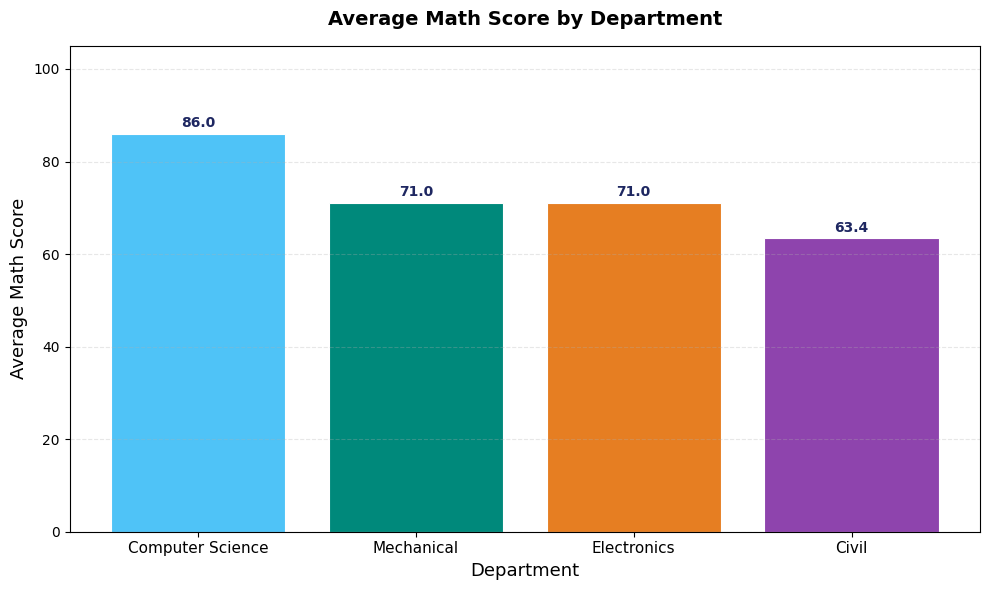

In [29]:
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Math Score by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [30]:
print('MISSING VALUES Quantity:')
print(df.isnull().sum())

MISSING VALUES Quantity:
student_id               0
name                     0
age                      0
gender                   1
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [31]:
print('Before fixing nulls:',df.isnull().sum().sum(),'total missing value')

df['gender'].fillna('Unknown',inplace=True)

print('After fixing nulls:',df.isnull().sum().sum(),'total missing value')

Before fixing nulls: 1 total missing value
After fixing nulls: 0 total missing value


In [32]:
print(df['gender'])

0        Male
1      Female
2        Male
3     Unknown
4        Male
5      Female
6        Male
7      Female
8        Male
9      Female
10       Male
11     Female
12       Male
13     Female
14       Male
15     Female
16       Male
17     Female
18       Male
19     Female
20       Male
21     Female
22       Male
23     Female
24       Male
25     Female
26       Male
27     Female
28       Male
29     Female
30     Female
Name: gender, dtype: object


In [33]:
print(f'Before duplication: {len(df)} rows')

print(f'Duplicate rows: {df.duplicated().sum()}')

Before duplication: 31 rows
Duplicate rows: 1


In [34]:
df.drop_duplicates()

print(f'\nAfter duplication: {len(df)} rows')


After duplication: 31 rows


In [35]:
API_KEY='bc3fbe89cc9d59da10ef9a471558cf74'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')

API configured for 8 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [36]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrices, or None on failure.
  """
  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params = params, timeout=10)

    if response.status_code==200:

      data = response.json()

      return{
          'city': city,
          'temperature' : round(data['main']['temp'], 1),
          'feels_like' : round(data['main']['feels_like'], 1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' : data['weather'][0]['description'].title(),
          'visibility' : data.get('visibility', 0)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None

print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record['temperature']}°C', {record['condition']})
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...
 Fetching: Mumbai...31.6°C {'Clear Sky'}
{'city': 'Mumbai', 'temperature': 31.6, 'feels_like': 38.6, 'humidity': 73, 'pressure': 1005, 'wind_speed': 5.22, 'condition': 'Clear Sky', 'visibility': 10000}
 Fetching: Delhi...39.8°C {'Overcast Clouds'}
{'city': 'Delhi', 'temperature': 39.8, 'feels_like': 39.1, 'humidity': 20, 'pressure': 999, 'wind_speed': 0.96, 'condition': 'Overcast Clouds', 'visibility': 10000}
 Fetching: Bangalore...29.3°C {'Overcast Clouds'}
{'city': 'Bangalore', 'temperature': 29.3, 'feels_like': 31.7, 'humidity': 61, 'pressure': 1008, 'wind_speed': 7.14, 'condition': 'Overcast Clouds', 'visibility': 10000}
 Fetching: Chennai...34.5°C {'Overcast Clouds'}
{'city': 'Chennai', 'temperature': 34.5, 'feels_like': 41.5, 'humidity': 57, 'pressure': 1002, 'wind_speed': 5.36, 'condition': 'Overcast Clouds', 'visibility': 10000}
 Fetching: Hyderabad...31°C {'Overcast Clouds'}
{'city': 'Hyderabad', 'temperature': 31, 'feels_like': 31.7, 'humidity': 45, 'pre

In [37]:
import pandas as pd
weather_df = pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index= False))
print(f'\nShape: {weather_df.shape}')

Weather DataFrame created:
     city  temperature  feels_like  humidity  pressure  wind_speed       condition  visibility
   Mumbai         31.6        38.6        73      1005        5.22       Clear Sky       10000
    Delhi         39.8        39.1        20       999        0.96 Overcast Clouds       10000
Bangalore         29.3        31.7        61      1008        7.14 Overcast Clouds       10000
  Chennai         34.5        41.5        57      1002        5.36 Overcast Clouds       10000
Hyderabad         31.0        31.7        45      1003        5.00 Overcast Clouds       10000
  Kolkata         38.0        42.6        38       995        3.02   Broken Clouds       10000
     Pune         36.3        36.4        29      1004        8.75      Few Clouds       10000
   Jaipur         38.4        38.8        26      1000        3.33       Clear Sky       10000

Shape: (8, 8)


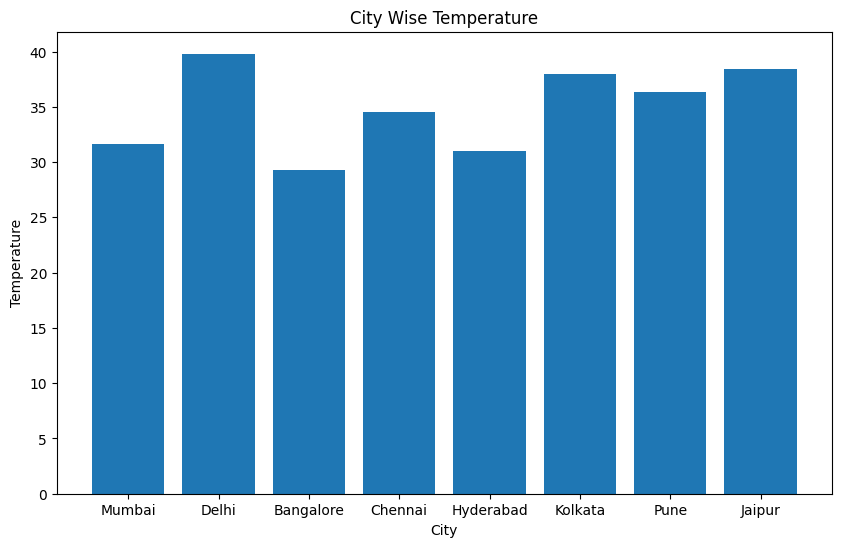

In [38]:


plt.figure(figsize=(10, 6))

plt.bar(
    weather_df['city'],
    weather_df['temperature']
)

plt.title('City Wise Temperature')
plt.xlabel('City')
plt.ylabel('Temperature')

plt.show()

In [39]:
spark=SparkSession.builder \
.appName('Day4_BigData_Sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()


print(f'Spark Session : {spark.version}')

Spark Session : 4.0.2


In [40]:
df_bronze = spark.read \
.option('header','true') \
.option('inferSchema','true') \
.csv('student_performance.csv')

print('BRONZE LAYER-Raw Data')
print(f'Rows : {df_bronze.count()}')
print(f'Columns : {len(df_bronze.columns)}')
print(f'Names : {df_bronze.columns}')

print()
df_bronze.printSchema()

BRONZE LAYER-Raw Data
Rows : 31
Columns : 13
Names : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

root
 |-- student_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- department: string (nullable = true)
 |-- semester: integer (nullable = true)
 |-- math_score: integer (nullable = true)
 |-- science_score: integer (nullable = true)
 |-- english_score: integer (nullable = true)
 |-- programming_score: integer (nullable = true)
 |-- attendance_percentage: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- admission_year: integer (nullable = true)



In [41]:
print('First 5 rows:')
df_bronze.show(5,truncate=False)

print('\nBasic statistics for numeric columns:')
df_bronze.select('name','department','attendance_percentage').describe().show()

print('Last 5 rows:')
df_bronze.tail(5)

First 5 rows:
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|name        |age|gender|department      |semester|math_score|science_score|english_score|programming_score|attendance_percentage|city     |admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|1001      |Aarav Sharma|19 |Male  |Computer Science|2       |85        |78           |72           |91               |92                   |Mumbai   |2023          |
|1002      |Priya Patel |20 |Female|Computer Science|2       |76        |82           |88           |79               |87                   |Ahmedabad|2023          |
|1003      |Rohit Verma |19 |Male  |Electronics     |2       |65        |74           |61           |55               |78                   |Delhi    |

[Row(student_id=1027, name='Gaurav Shukla', age=21, gender='Male', department='Computer Science', semester=2, math_score=84, science_score=79, english_score=75, programming_score=87, attendance_percentage=87, city='Lucknow', admission_year=2023),
 Row(student_id=1028, name='Sunita Pillai', age=19, gender='Female', department='Civil', semester=2, math_score=60, science_score=65, english_score=68, programming_score=39, attendance_percentage=73, city='Thiruvananthapuram', admission_year=2023),
 Row(student_id=1029, name='Nitin Jain', age=20, gender='Male', department='Mechanical', semester=2, math_score=75, science_score=76, english_score=70, programming_score=50, attendance_percentage=84, city='Indore', admission_year=2023),
 Row(student_id=1030, name='Akanksha Yadav', age=19, gender='Female', department='Computer Science', semester=2, math_score=91, science_score=93, english_score=87, programming_score=94, attendance_percentage=95, city='Agra', admission_year=2023),
 Row(student_id=1030

In [48]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print(f'Total students:{len(X)}')
print(f'Training students:{len(X_train)}({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing students:{len(X_test)}({len(X_test)/len(X)*100:.0f}%)')
print(f'\nTraining target range:{y_train.min()}-{y_train.max()}')
print(f'Testing target range:{y_test.min()}-{y_test.max()}')

Total students:31
Training students:24(77%)
Testing students:7(23%)

Training target range:56-93
Testing target range:60-95


In [51]:




# Target column
y = df['Programming_Score']

# Features
X = df.drop('Programming_Score', axis=1)

# Remove name column if it exists
if 'Student_Name' in X.columns:
    X = X.drop('Student_Name', axis=1)

if 'Name' in X.columns:
    X = X.drop('Name', axis=1)

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale training and testing data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

print(f"Training feature mean (should be ≈ 0): {X_train_scaled.mean():.4f}")
print(f"Training feature std (should be ≈ 1): {X_train_scaled.std():.4f}")

KeyError: 'Programming_Score'